# Customer Retention Intelligence Platform

## Objective
Predict customer churn, identify high-risk customers, estimate revenue at risk, and provide retention recommendations.

## Tools Used
- Python
- Pandas
- Matplotlib
- Scikit-Learn
- Tableau
- SQL

## Dataset
Telco Customer Churn Dataset

In [157]:
import pandas as pd

df = pd.read_csv('/content/customer_churn_cleaned.csv')

## Data Understanding


In [158]:
df.head()


,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn,churn_flag,senior_citizen_label,tenure_group,monthly_charge_group
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,Non-Senior Citizen,0-12 Months,Low Charge
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,One year,No,Mailed check,56.95,1889.50,No,0,Non-Senior Citizen,25-48 Months,Medium Charge
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,Non-Senior Citizen,0-12 Months,Medium Charge
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,Non-Senior Citizen,25-48 Months,Medium Charge
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,Non-Senior Citizen,0-12 Months,High Charge


In [159]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 25 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerid            7032 non-null   object 
 1   gender                7032 non-null   object 
 2   seniorcitizen         7032 non-null   int64  
 3   partner               7032 non-null   object 
 4   dependents            7032 non-null   object 
 5   tenure                7032 non-null   int64  
 6   phoneservice          7032 non-null   object 
 7   multiplelines         7032 non-null   object 
 8   internetservice       7032 non-null   object 
 9   onlinesecurity        7032 non-null   object 
 10  onlinebackup          7032 non-null   object 
 11  deviceprotection      7032 non-null   object 
 12  techsupport           7032 non-null   object 
 13  streamingtv           7032 non-null   object 
 14  streamingmovies       7032 non-null   object 
 15  contract             

## Dataset Overview

This dataset contains customer demographic, service usage, billing, and churn information for a telecommunications company.

### Key Business Question
Why are customers leaving (churning), and how can the company proactively retain them?

### Target Variable
- churn
    - Yes = Customer left
    - No = Customer stayed

### Dataset Size
- 7,032 customers
- 25 columns

## Exploratory Data Analysis (EDA)

In this section, we explore customer churn patterns and identify factors that may contribute to customer attrition.

In [160]:
print("Dataset Shape:")
print(df.shape)


Dataset Shape:
(7032, 25)


In [161]:
print(df.columns.tolist())

['customerid', 'gender', 'seniorcitizen', 'partner', 'dependents', 'tenure', 'phoneservice', 'multiplelines', 'internetservice', 'onlinesecurity', 'onlinebackup', 'deviceprotection', 'techsupport', 'streamingtv', 'streamingmovies', 'contract', 'paperlessbilling', 'paymentmethod', 'monthlycharges', 'totalcharges', 'churn', 'churn_flag', 'senior_citizen_label', 'tenure_group', 'monthly_charge_group']


In [162]:
df["churn"].value_counts()

,count
churn,
No,5163
Yes,1869


In [163]:
round(
    df["churn"].value_counts(normalize=True) * 100,
    2
)

,proportion
churn,
No,73.42
Yes,26.58


### Insight

The churn percentage indicates the proportion of customers who have left the company.

A higher churn rate suggests potential issues with customer satisfaction, pricing, service quality, or contract structure.

In [164]:
total_customers = len(df)

churned_customers = len(
    df[df["churn"] == "Yes"]
)

churn_rate = (
    churned_customers / total_customers
) * 100

print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Churn Rate:", round(churn_rate,2), "%")

Total Customers: 7032
Churned Customers: 1869
Churn Rate: 26.58 %


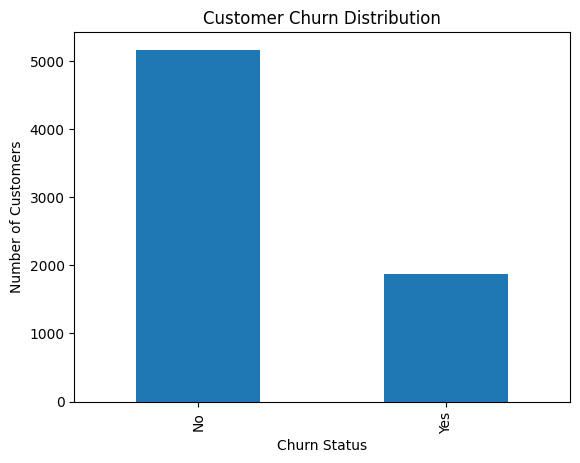

In [165]:
import matplotlib.pyplot as plt

df["churn"].value_counts().plot(kind="bar")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")

plt.show()

### Business Insight #1: Overall Customer Churn

- Total Customers: 7,032
- Churned Customers: 1,869
- Churn Rate: 26.58%

Approximately 1 in 4 customers have left the company. This represents a substantial risk to recurring revenue and indicates the need for proactive customer retention strategies.

The next step is to identify which customer segments contribute most to churn and develop targeted retention actions.

## Churn Analysis by Contract Type

This analysis evaluates whether contract type influences customer churn behavior.


In [166]:
pd.crosstab(
    df["contract"],
    df["churn"]
)

churn,No,Yes
contract,,
Month-to-month,2220,1655
One year,1306,166
Two year,1637,48


In [167]:
contract_churn = pd.crosstab(
    df["contract"],
    df["churn"],
    normalize="index"
) * 100

round(contract_churn, 2)

churn,No,Yes
contract,,
Month-to-month,57.29,42.71
One year,88.72,11.28
Two year,97.15,2.85


### Business Insight #2: Contract Type and Customer Churn

Contract type has a significant impact on customer retention.

#### Churn Rates by Contract Type

- Month-to-Month: 42.71%
- One-Year Contract: 11.28%
- Two-Year Contract: 2.85%

Customers on month-to-month contracts are substantially more likely to leave compared to customers on longer-term contracts.

The analysis suggests that contract commitment is strongly associated with customer retention.

#### Business Recommendation

Develop targeted retention campaigns encouraging month-to-month customers to migrate to one-year or two-year contracts through loyalty discounts, bundled services, or promotional pricing.

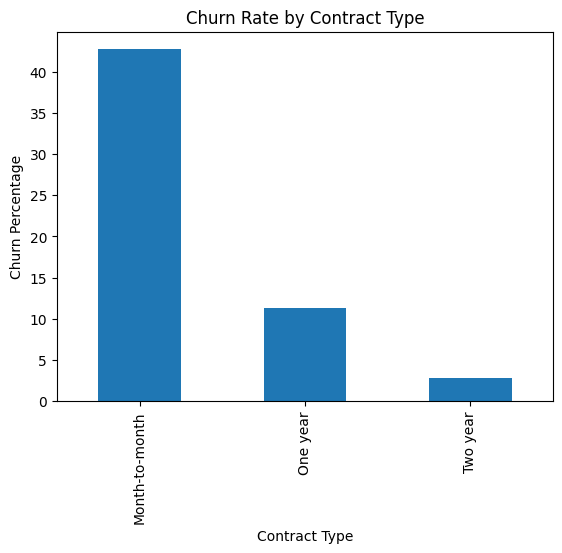

In [168]:
contract_churn["Yes"].plot(
    kind="bar"
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Percentage")

plt.show()

In [169]:
internet_churn = pd.crosstab(
    df["internetservice"],
    df["churn"],
    normalize="index"
) * 100

round(internet_churn, 2)

churn,No,Yes
internetservice,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


## Churn Analysis by Internet Service

This analysis examines whether internet service type influences customer churn behavior.


In [170]:
internet_churn = pd.crosstab(
    df["internetservice"],
    df["churn"],
    normalize="index"
) * 100

round(internet_churn, 2)

churn,No,Yes
internetservice,,
DSL,81.00,19.00
Fiber optic,58.11,41.89
No,92.57,7.43


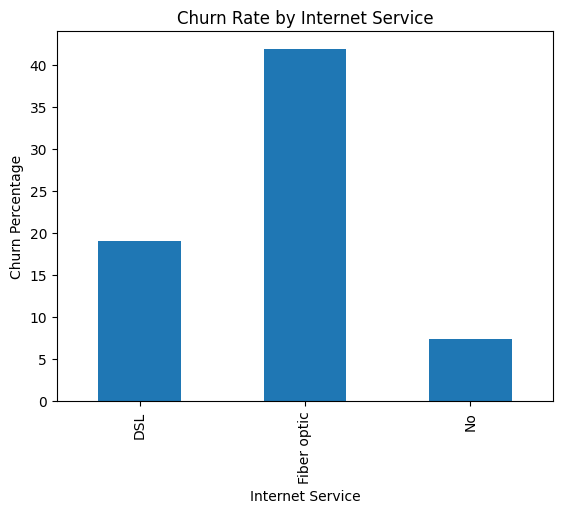

In [171]:
internet_churn["Yes"].plot(
    kind="bar"
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn Percentage")

plt.show()

## Churn Analysis by Payment Method

This analysis investigates whether payment methods are associated with customer churn.

In [172]:
payment_churn = pd.crosstab(
    df["paymentmethod"],
    df["churn"],
    normalize="index"
) * 100

round(payment_churn, 2)

churn,No,Yes
paymentmethod,,
Bank transfer (automatic),83.27,16.73
Credit card (automatic),84.75,15.25
Electronic check,54.71,45.29
Mailed check,80.80,19.20


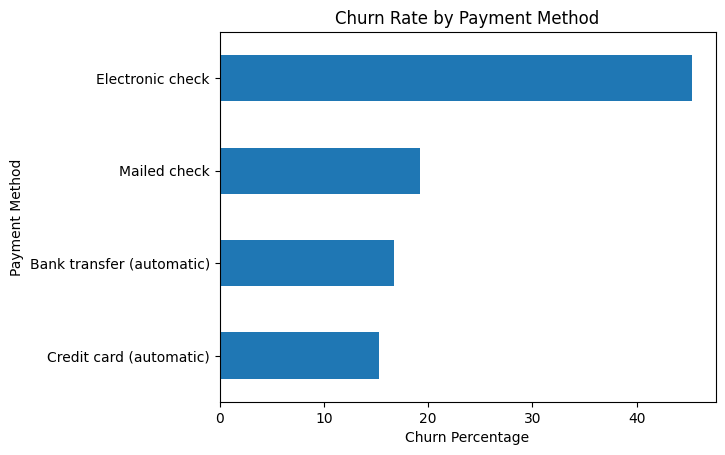

In [173]:
payment_churn["Yes"].sort_values().plot(
    kind="barh"
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Churn Percentage")
plt.ylabel("Payment Method")

plt.show()

## Revenue Impact Analysis

This analysis estimates the financial impact of customer churn and identifies revenue at risk.

In [174]:
df["annual_revenue"] = df["monthlycharges"] * 12

df[["monthlycharges", "annual_revenue"]].head()

,monthlycharges,annual_revenue
0,29.85,358.2
1,56.95,683.4
2,53.85,646.2
3,42.30,507.6
4,70.70,848.4


In [175]:
df.groupby("churn")["annual_revenue"].sum()

,annual_revenue
churn,
No,3798361.8
Yes,1669570.2


In [176]:
revenue_lost = df[df["churn"] == "Yes"]["annual_revenue"].sum()

print(f"Annual Revenue Lost: ${revenue_lost:,.2f}")

Annual Revenue Lost: $1,669,570.20


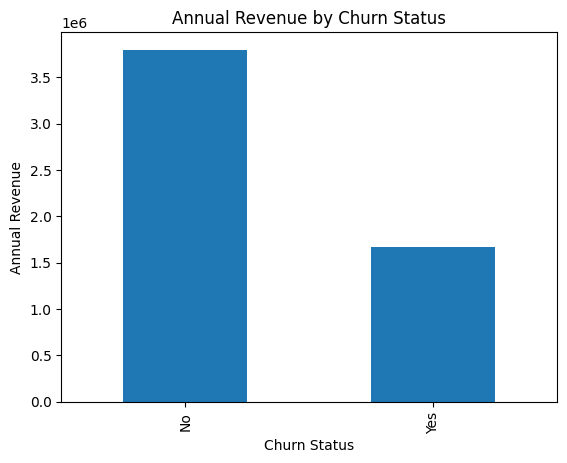

In [177]:
revenue_by_churn = df.groupby("churn")["annual_revenue"].sum()

revenue_by_churn.plot(kind="bar")

plt.title("Annual Revenue by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Annual Revenue")

plt.show()

### Business Insight #3: Revenue Impact of Customer Churn

Customers who churn represent a substantial amount of annual recurring revenue.

Although churned customers account for only 26.58% of the customer base, they contribute significantly to revenue loss.

Reducing churn through targeted retention strategies could protect recurring revenue and improve long-term profitability.

This highlights the importance of identifying high-risk customers before they leave.

## Churn Prediction Model

The objective of this model is to predict whether a customer is likely to churn based on demographic, service, and billing information.

In [178]:
features = [
    "tenure",
    "monthlycharges",
    "totalcharges",
    "seniorcitizen"
]

X = df[features]

y = df["churn_flag"]

In [179]:
X.head()

,tenure,monthlycharges,totalcharges,seniorcitizen
0,1,29.85,29.85,0
1,34,56.95,1889.50,0
2,2,53.85,108.15,0
3,45,42.30,1840.75,0
4,2,70.70,151.65,0


In [180]:
y.head()

,churn_flag
0,0
1,0
2,1
3,0
4,1


In [181]:
from sklearn.model_selection import train_test_split

In [182]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [183]:
print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 5625
Testing Rows: 1407


## Logistic Regression Model

Logistic Regression is a classification algorithm used to predict whether a customer will churn (1) or remain (0).

This model serves as a baseline predictive model for customer churn analysis.

In [184]:
from sklearn.linear_model import LogisticRegression

In [185]:
model = LogisticRegression(max_iter=1000)

In [186]:
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [187]:
y_pred = model.predict(X_test)

y_pred[:10]

array([0, 0, 1, 0, 0, 0, 0, 1, 0, 0])

In [188]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2%}")

Model Accuracy: 78.04%


In [189]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.91      0.86      1033
           1       0.62      0.44      0.51       374

    accuracy                           0.78      1407
   macro avg       0.72      0.67      0.69      1407
weighted avg       0.77      0.78      0.77      1407



### Business Insight #4: Churn Prediction Model

A Logistic Regression model was developed to predict customer churn using customer tenure, billing, and demographic information.

The model achieved an accuracy of 78.04%.

This model can be used to proactively identify customers at risk of leaving and support targeted retention strategies before churn occurs.

## Customer Risk Scoring

In [190]:
churn_probabilities = model.predict_proba(X_test)

churn_probabilities[:5]

array([[0.9854747 , 0.0145253 ],
       [0.89527131, 0.10472869],
       [0.34608599, 0.65391401],
       [0.90669969, 0.09330031],
       [0.75962269, 0.24037731]])

In [191]:
risk_scores = churn_probabilities[:, 1] * 100

risk_scores[:10]

array([ 1.45252951, 10.47286876, 65.39140053,  9.33003105, 24.03773139,
       28.05747901, 17.56115293, 70.83038673, 24.40184531,  5.52318491])

In [192]:
risk_df = X_test.copy()

risk_df["Actual_Churn"] = y_test.values
risk_df["Risk_Score"] = risk_scores.round(2)

risk_df.head()

,tenure,monthlycharges,totalcharges,seniorcitizen,Actual_Churn,Risk_Score
2476,61,25.00,1501.75,1,0,1.45
6773,19,24.70,465.85,0,0,10.47
6116,13,102.25,1359.00,0,1,65.39
3047,37,55.05,2030.75,0,0,9.33
4092,6,29.45,161.45,0,0,24.04


In [193]:
def risk_category(score):
    if score >= 70:
        return "High Risk"
    elif score >= 40:
        return "Medium Risk"
    else:
        return "Low Risk"

In [194]:
risk_df["Risk_Level"] = risk_df["Risk_Score"].apply(risk_category)

risk_df.head()

,tenure,monthlycharges,totalcharges,seniorcitizen,Actual_Churn,Risk_Score,Risk_Level
2476,61,25.00,1501.75,1,0,1.45,Low Risk
6773,19,24.70,465.85,0,0,10.47,Low Risk
6116,13,102.25,1359.00,0,1,65.39,Medium Risk
3047,37,55.05,2030.75,0,0,9.33,Low Risk
4092,6,29.45,161.45,0,0,24.04,Low Risk


In [195]:
risk_df["Risk_Level"].value_counts()

,count
Risk_Level,
Low Risk,1018
Medium Risk,324
High Risk,65


### Business Insight #5: Customer Risk Segmentation

The churn prediction model classified customers into three risk categories:

- High Risk: 65 customers
- Medium Risk: 324 customers
- Low Risk: 1,018 customers

High-risk customers should be prioritized for immediate retention efforts, while medium-risk customers should be monitored through targeted engagement campaigns.

This segmentation enables more efficient allocation of retention resources and supports proactive customer management.

In [196]:
risk_df["Annual_Revenue"] = risk_df["monthlycharges"] * 12

risk_df.head()

,tenure,monthlycharges,totalcharges,seniorcitizen,Actual_Churn,Risk_Score,Risk_Level,Annual_Revenue
2476,61,25.00,1501.75,1,0,1.45,Low Risk,300.0
6773,19,24.70,465.85,0,0,10.47,Low Risk,296.4
6116,13,102.25,1359.00,0,1,65.39,Medium Risk,1227.0
3047,37,55.05,2030.75,0,0,9.33,Low Risk,660.6
4092,6,29.45,161.45,0,0,24.04,Low Risk,353.4


In [197]:
revenue_at_risk = risk_df.groupby(
    "Risk_Level"
)["Annual_Revenue"].sum()

revenue_at_risk

,Annual_Revenue
Risk_Level,
High Risk,68502.0
Low Risk,731319.0
Medium Risk,301034.4


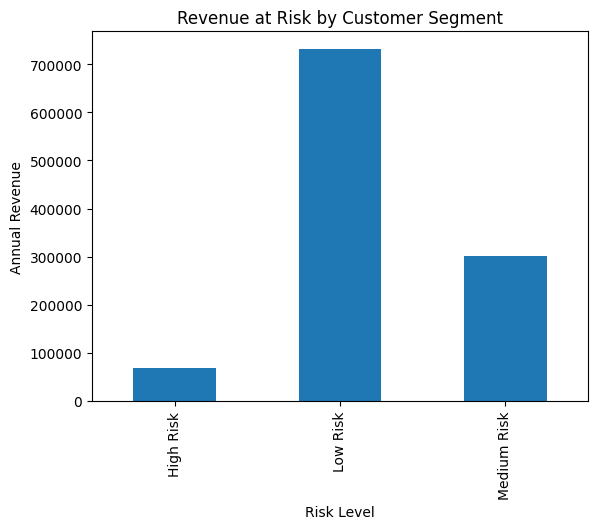

In [198]:
revenue_at_risk.plot(
    kind="bar"
)

plt.title("Revenue at Risk by Customer Segment")
plt.xlabel("Risk Level")
plt.ylabel("Annual Revenue")

plt.show()

In [199]:
high_risk_customers = risk_df[
    risk_df["Risk_Level"] == "High Risk"
]

high_risk_customers.sort_values(
    "Risk_Score",
    ascending=False
).head(10)

,tenure,monthlycharges,totalcharges,seniorcitizen,Actual_Churn,Risk_Score,Risk_Level,Annual_Revenue
5924,3,105.00,294.45,1,1,87.22,High Risk,1260.0
31,2,95.50,181.65,1,0,84.57,High Risk,1146.0
1971,1,93.55,93.55,1,1,84.56,High Risk,1122.6
6359,2,94.00,181.70,1,1,84.00,High Risk,1128.0
3154,3,94.85,335.75,1,0,83.74,High Risk,1138.2
4610,4,94.75,422.40,1,0,82.94,High Risk,1137.0
5774,1,89.30,89.30,1,1,82.90,High Risk,1071.6
994,4,94.30,424.45,1,1,82.76,High Risk,1131.6
1595,1,88.80,88.80,1,1,82.70,High Risk,1065.6
2275,8,100.15,908.55,1,0,82.33,High Risk,1201.8


### Business Insight #6: Revenue at Risk

The churn prediction model identifies customers representing significant annual recurring revenue that may be lost if retention actions are not implemented.

By prioritizing high-risk customers and targeting retention campaigns effectively, the company can reduce revenue loss and improve long-term customer value.

The Customer Retention Intelligence Platform enables proactive customer management by combining churn prediction, risk segmentation, and revenue impact analysis.

In [200]:
risk_df.to_csv(
    "customer_risk_scores.csv",
    index=False
)

print("Export Complete")

Export Complete


## Random Forest Model

This section builds a Random Forest model to compare against the Logistic Regression baseline model.

In [201]:
from sklearn.ensemble import RandomForestClassifier

In [202]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [203]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [204]:
rf_pred = rf_model.predict(X_test)

In [205]:
rf_accuracy = accuracy_score(y_test, rf_pred)

print(f"Random Forest Accuracy: {rf_accuracy:.2%}")

Random Forest Accuracy: 75.41%


In [206]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.87      0.84      1033
           1       0.55      0.43      0.48       374

    accuracy                           0.75      1407
   macro avg       0.68      0.65      0.66      1407
weighted avg       0.74      0.75      0.74      1407



### Model Comparison

Two machine learning models were evaluated:

| Model | Accuracy |
|---------|----------|
| Logistic Regression | 78.04% |
| Random Forest | 75.41% |

Logistic Regression outperformed Random Forest on this dataset and was selected as the final predictive model.

This result suggests that customer churn patterns are relatively linear and can be effectively captured using Logistic Regression.

## Feature Importance Analysis

This section identifies the most important factors influencing customer churn.

In [207]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,monthlycharges,0.385134
2,totalcharges,0.352152
0,tenure,0.234023
3,seniorcitizen,0.028691


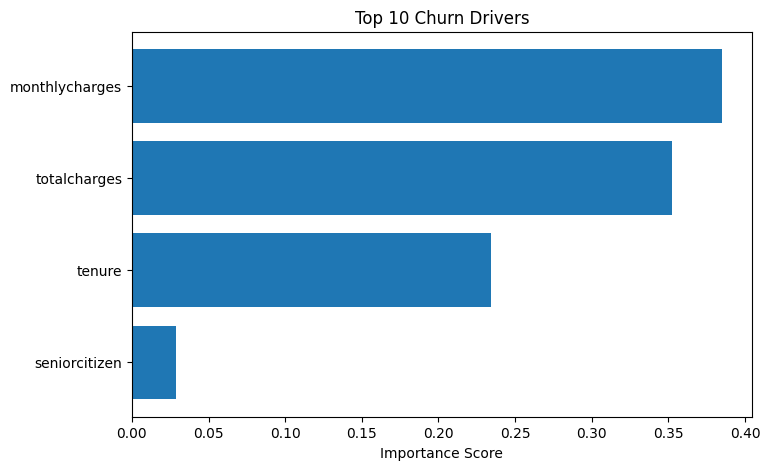

In [208]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.title('Top 10 Churn Drivers')

plt.xlabel('Importance Score')

plt.gca().invert_yaxis()

plt.show()

### Feature Importance Insights

The Random Forest model identified the following key drivers of customer churn:

1. Monthly Charges
2. Total Charges
3. Customer Tenure
4. Senior Citizen Status

Customers with higher monthly charges and shorter tenure periods were more likely to churn. These findings suggest that pricing strategies and early customer engagement programs may play a significant role in improving customer retention.